In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# In Jupyter, this helps show plots inline
# %matplotlib inline

def read_spline_file(fname):
    with open(fname, "r") as input_data:
        listi = []
        images = []
        spline = []

        for i, line in enumerate(input_data):
            line = line.strip()
            if not line:
                listi.append("E")
            else:
                parts = line.split()
                listi.append(parts)
                if parts[0].upper() == "INTERP.:":
                    spline.append(i)
                if parts[0].upper() == "IMAGES:":
                    images.append(i)

    return listi, images, spline


def read_images(start_point, listi):
    arclength = []
    energy = []
    index = start_point

    while index < len(listi):
        entry = listi[index]
        if entry == "E" or entry[0].upper() == "INTERP.:":
            break
        arclength.append(float(entry[1]))
        energy.append(float(entry[2]))
        index += 1

    return arclength, energy


def read_spline(start_point, listi):
    arclength = []
    energy = []
    index = start_point

    while index < len(listi):
        entry = listi[index]
        if entry == "E" or entry[0].upper() == "ITERATION:":
            break
        arclength.append(float(entry[1]))
        energy.append(float(entry[2]))
        index += 1

    return arclength, energy


def plot_orca_neb_interp(fname, start_from=0, end_at=-1, show_last=True):
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"Cannot find file: {fname}")

    print("==========================================")
    print("     Optimization Profile: ORCA-NEB")
    print("==========================================")
    print(f"Reading: {fname}")

    listi, start_images, start_spline = read_spline_file(fname)

    if len(start_images) != len(start_spline):
        raise RuntimeError("Corrupt .interp file: number of Images and Interp sections do not match.")

    no_of_iters = len(start_spline)
    print(f"Detected {no_of_iters} iteration(s)")

    if no_of_iters == 0:
        raise RuntimeError("No INTERP sections found in file.")

    if end_at == -1:
        end_at = no_of_iters

    if start_from < 0 or end_at < 0 or start_from > no_of_iters or end_at > no_of_iters or start_from >= end_at:
        raise RuntimeError(
            f"Invalid range: start_from={start_from}, end_at={end_at}, total_iterations={no_of_iters}"
        )

    # Plot all requested iterations on one figure
    plt.figure(figsize=(8, 5))

    last_arcS = None
    last_Eimg = None
    last_arcS2 = None
    last_Eimg2 = None

    for i in range(start_from, end_at):
        arcS, Eimg = read_images(start_images[i] + 1, listi)
        arcS2, Eimg2 = read_spline(start_spline[i] + 1, listi)

        last_arcS, last_Eimg = arcS, Eimg
        last_arcS2, last_Eimg2 = arcS2, Eimg2

        if i == start_from:
            plt.plot(arcS2, Eimg2, "-k", linewidth=1.5, label=f"iter {i} (initial)")
            plt.plot(arcS, Eimg, ".k", markersize=6)
        elif i == end_at - 1:
            plt.plot(arcS2, Eimg2, "-", color=[0.6, 0.0, 0.0], linewidth=1.8, label=f"iter {i} (final)")
            plt.plot(arcS, Eimg, ".", color=[0.6, 0.0, 0.0], markersize=8)
        else:
            plt.plot(arcS2, Eimg2, "-", color=[0.5, 0.5, 0.5], linewidth=1.0)
            plt.plot(arcS, Eimg, ".", color=[0.5, 0.5, 0.5], markersize=4)

    plt.xlabel("Displacement [Bohr]", fontsize=13)
    plt.ylabel("Energy [Ha]", fontsize=13)
    plt.title(f"ORCA-NEB profile: iterations {start_from} to {end_at - 1}", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: show the final iteration alone
    if show_last and last_arcS is not None and last_arcS2 is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(last_arcS2, last_Eimg2, "-", color=[0.6, 0.0, 0.0], linewidth=1.8)
        plt.plot(last_arcS, last_Eimg, ".", color=[0.6, 0.0, 0.0], markersize=8)
        plt.xlabel("Displacement [Bohr]", fontsize=13)
        plt.ylabel("Energy [Ha]", fontsize=13)
        plt.title(f"Final shown iteration: {end_at - 1}", fontsize=14)
        plt.tight_layout()
        plt.show()

     Optimization Profile: ORCA-NEB
Reading: H3_rxn.interp
Detected 29 iteration(s)


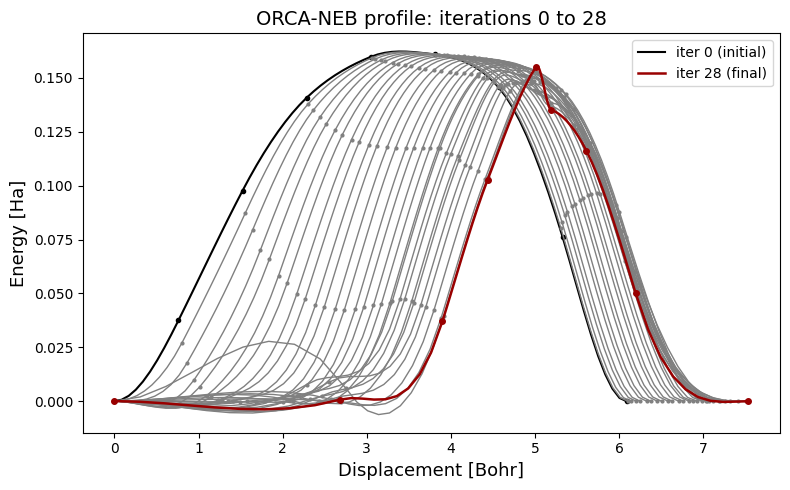

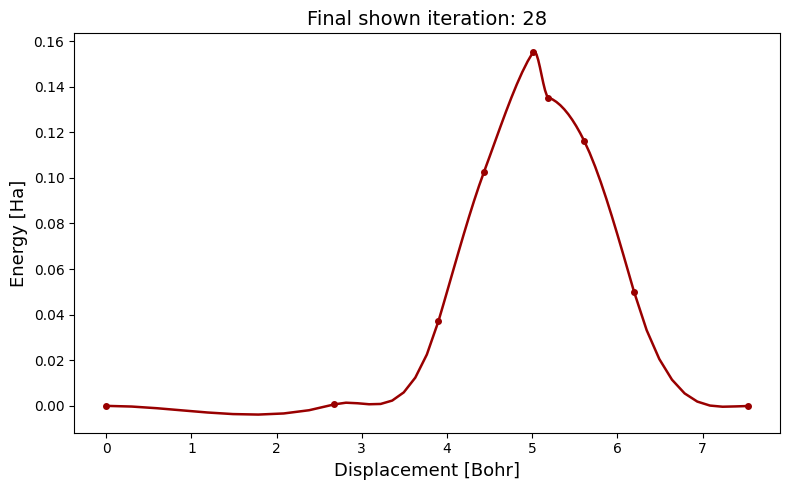

In [4]:
fname = r"H3_rxn.interp"
plot_orca_neb_interp(fname)